The present notebook computes the time taken (on average) to do a single transport coefficient calculation, for tracer diffusion in a BCC solid with the 60-degree roto-translation mechanism.

In [1]:
import numpy as np
import onsager.crystal as crystal
from onsager.crystalStars import zeroclean
from onsager.OnsagerCalc import dumbbellMediated
from onsager.crystal import DB_disp, DB_disp4, pureDBContainer, mixedDBContainer
from onsager.DB_structs import dumbbell, SdPair, jump, connector

In [2]:
import matplotlib.pyplot as plt
import scipy.optimize as sopt
from tqdm import tqdm
import pickle
import time

In [3]:
# make a BCC lattice
# We'll modify the jumpnetwork to keep only the 60 degree reorientational jumps.
a0 = 1.0
latt = np.array([[1., 0., 0.], [0., 1., 0.], [0., 0., 1.]]) * a0
Fe = crystal.Crystal(latt, [[np.array([0., 0., 0.]), np.array([0.5, 0.5, 0.5])]], ["Fe"])
# Now give it the orientations - for BCC it's [110]
o = np.array([1.,1.,0.])/np.linalg.norm(np.array([1.,1.,0.]))*a0/4
famp0 = [o.copy()]
family = [famp0]
pdbcontainer_fe = pureDBContainer(Fe, 0, family)
mdbcontainer_fe = mixedDBContainer(Fe, 0, family)
jcut = np.sqrt(3)*1.01*a0/2.
jset0, jset2 = pdbcontainer_fe.jumpnetwork(jcut, 0.01, 0.01), mdbcontainer_fe.jumpnetwork(jcut, 0.01, 0.01)
print(Fe)

#Lattice:
  a1 = [0.5 0.5 0.5]
  a2 = [-0.5  0.5 -0.5]
  a3 = [-0.5 -0.5  0.5]
#Basis:
  (Fe) 0.0 = [0. 0. 0.]


In [4]:
# Modify jnet0
jnet0 = jset0[0]
jnet0_indexed = jset0[1]
# Let's try to sort the jumps according to closest distance
# except rotational jumps, we don't want them.
z = np.zeros(3)
indices = []

for jt, jlist in enumerate(jnet0):
    if np.allclose(jnet0_indexed[jt][0][1], z):
        continue
    indices.append(jt)
    
def sortkey(entry):
    jmp = jnet0[entry][0]
    or1 = pdbcontainer_fe.iorlist[jmp.state1.iorind][1]
    or2 = pdbcontainer_fe.iorlist[jmp.state2.iorind][1]
    dx = DB_disp(pdbcontainer_fe, jmp.state1, jmp.state2)
    dx1 = np.linalg.norm(jmp.c1*or1/2.)
    dx2 = np.linalg.norm(dx + jmp.c2*or2/2. - jmp.c1*or1/2.)
    dx3 = np.linalg.norm(-jmp.c2*or2/2.)
    return dx1+dx2+dx3
ind_sort = sorted(indices, key=sortkey)

In [5]:
# Let's check if we got the correct jump
print(jnet0[ind_sort[0]][0])

Jump object:
Initial state:
	dumbbell : (i, or) index = 2, lattice vector = [0 0 0]
Final state:
	dumbbell : (i, or) index = 0, lattice vector = [-1 -1 -1]
Jumping from c1 = -1 to c2 = -1



In [6]:
pdbcontainer_fe.iorlist

[(0, array([ 0.1767767,  0.       , -0.1767767])),
 (0, array([0.1767767, 0.       , 0.1767767])),
 (0, array([0.       , 0.1767767, 0.1767767])),
 (0, array([ 0.       , -0.1767767,  0.1767767])),
 (0, array([ 0.1767767, -0.1767767,  0.       ])),
 (0, array([-0.1767767, -0.1767767,  0.       ]))]

In [7]:
# take only the lowest displacement jump
# that is the jump we want.
jset0new = ([jnet0[ind_sort[0]]], [jnet0_indexed[ind_sort[0]]])

In [8]:
# Now, we modify the mixed dumbbell jumpnetwork to also give the lowest displacement jump
# Modify jnet0
jnet2 = jset2[0]
jnet2_indexed = jset2[1]
# Let's try to sort the jumps according to closest distance
# we don't want the rotational jumps as before.
z = np.zeros(3)
indices2 = []
for jt, jlist in enumerate(jnet2):
    if np.allclose(jnet2_indexed[jt][0][1], z):
        continue
    indices2.append(jt)    
print(indices2)

def sortkey2(entry):
    jmp = jnet2[entry][0]
    or1 = mdbcontainer_fe.iorlist[jmp.state1.db.iorind][1]
    or2 = mdbcontainer_fe.iorlist[jmp.state2.db.iorind][1]
    dx = DB_disp(mdbcontainer_fe, jmp.state1, jmp.state2)
    # c1 and c2 are always +1 for mixed dumbbell jumps.
    dx1 = np.linalg.norm(jmp.c1*or1/2.)
    dx2 = np.linalg.norm(dx + jmp.c2*or2/2. - jmp.c1*or1/2.)
    dx3 = np.linalg.norm(-jmp.c2*or2/2.)
    return dx1+dx2+dx3
ind_sort2 = sorted(indices2, key=sortkey2)
print(ind_sort2)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
[2, 5, 4, 1, 3, 0, 8, 6, 10, 11, 14, 9, 13, 7, 12, 15, 16]


In [9]:
# check if we have the correct type of jump
print(jnet2[ind_sort2[0]][0])

Jump object:
Initial state:
	Solute loctation:basis index = 0, lattice vector = [0 0 0]
	dumbbell : (i, or) index = 6, lattice vector = [0 0 0]
Final state:
	Solute loctation :basis index = 0, lattice vector = [0 0 1]
	dumbbell : (i, or) index = 5, lattice vector = [0 0 1]
Jumping from c1 = 1 to c2 = 1


In [10]:
for tup in mdbcontainer_fe.iorlist:
    print(tup)

(0, array([ 0.1767767,  0.       , -0.1767767]))
(0, array([0.1767767, 0.       , 0.1767767]))
(0, array([0.       , 0.1767767, 0.1767767]))
(0, array([-0.1767767,  0.       , -0.1767767]))
(0, array([ 0.       , -0.1767767,  0.1767767]))
(0, array([ 0.       ,  0.1767767, -0.1767767]))
(0, array([-0.1767767,  0.       ,  0.1767767]))
(0, array([ 0.       , -0.1767767, -0.1767767]))
(0, array([ 0.1767767, -0.1767767,  0.       ]))
(0, array([-0.1767767, -0.1767767,  0.       ]))
(0, array([0.1767767, 0.1767767, 0.       ]))
(0, array([-0.1767767,  0.1767767,  0.       ]))


In [11]:
# take only the lowest displacement jump
# that is the jump we want.
jset2new = ([jnet2[ind_sort2[0]]], [jnet2_indexed[ind_sort2[0]]])

In [12]:
from IPython.utils import io
def sortkey43(entry):
    jmp = jnet43[entry][0] # This is an omega4 jump
    if not jmp.c2 == -1:
        print(c2)
    or1 = pdbcontainer_fe.iorlist[jmp.state1.db.iorind][1]
    or2 = mdbcontainer_fe.iorlist[jmp.state2.db.iorind][1]
    dx = DB_disp4(pdbcontainer_fe, mdbcontainer_fe, jmp.state1, jmp.state2)
    # remember that c2 is -1 for an omega4 jump
    dx1 = np.linalg.norm(jmp.c1*or1/2.)
    dx2 = np.linalg.norm(dx - or2/2. - jmp.c1*or1/2.)
    dx3 = np.linalg.norm(jmp.c2*or2/2.)
    return dx1+dx2+dx3

In the following shell, we'll create onsagercalculators with increasingly large sizes. Note that the time to create the calculators are not taken into account in our timing tests, since once created, they can be used across all temperatures without change, and can also in principle be serialized (such as using pickle) for re-use later on. For information, we do print the time to generate the calculators (in seconds). We find that even larger calculators with 1nn_4 kinetic shells can be generated in about 15-20 minutes.

In [14]:
# Now, we construct the Onsager calculator with these non-local jump sets.
OnsagerCals = []
ThermShellSizes = [1, 2, 3]
Generation_times = []
print("Calculator generation times")
print("N_therm \t time")
for th in ThermShellSizes:
    
    start = time.time()
    with io.capture_output() as captured:
        onsagercalculator = dumbbellMediated(pdbcontainer_fe, mdbcontainer_fe, jset0new, jset2new, jcut,
                                         0.01, 0.01, 0.01, NGFmax=4, Nthermo=th)

    # Next, we must also modify the omega3 and omega4 jump lists
    jnet43 = onsagercalculator.jnet43
    jnet43_indexed = onsagercalculator.jnet43_indexed
    # Let's try to sort the jumps according to closest distance
    # we don't want the rotational jumps as before.

    z = np.zeros(3)
    indices43 = []
    for jt, jlist in enumerate(jnet43):
        if np.allclose(jnet43_indexed[jt][0][1], z):
            continue
        indices43.append(jt)

    ind_sort43 = sorted(indices43, key=sortkey43)
    onsagercalculator.regenerate43([ind_sort43[0]])

    OnsagerCals.append(onsagercalculator)
    Generation_times.append(time.time() - start)
    print("{} \t \t {}".format(th, time.time() - start))

Calculator generation times
N_therm 	 time
1 	 	 57.266112089157104
2 	 	 301.14040422439575
3 	 	 1135.0497770309448


In the following shell, we'll compute our times. Note that timing results will depend on hardware conditions and other factors, but typically they should stay within the same range as reported in our paper.

In [15]:
Nstates = []
NVecStars = []
NGFStars = []
CalcTimes = []

for th in ThermShellSizes:
    onsg = OnsagerCals[th-1]
    kT = 1

    predb0, enedb0 = np.ones(len(onsg.vkinetic.starset.pdbcontainer.symorlist)), \
                     np.zeros(len(onsg.vkinetic.starset.pdbcontainer.symorlist))

    preS, eneS = np.ones(
        len(onsg.vkinetic.starset.crys.sitelist(onsg.vkinetic.starset.chem))), \
                 np.zeros(len(onsg.vkinetic.starset.crys.sitelist(
                     onsg.vkinetic.starset.chem)))

    # These are the interaction or the excess energies and pre-factors for solutes and dumbbells.
    # The energies will all be zero.
    preSdb, eneSdb = np.ones(onsg.thermo.mixedstartindex), \
                     np.zeros(onsg.thermo.mixedstartindex)

    predb2, enedb2 = predb0.copy(), enedb0.copy()

    preT0, eneT0 = np.ones(len(onsg.vkinetic.starset.jnet0)), np.zeros(len(onsg.jnet0))
    preT2, eneT2 = preT0.copy(), eneT0.copy()
    preT1, eneT1 = np.ones(len(onsg.jnet1)), np.array([eneT0[onsg.om1types[jt]] for jt in
                                                                    range(len(onsg.jnet1))])

    preT43, eneT43 = np.ones(len(onsg.jnet43)), eneT0.copy()

    # 1b. Now get the beta*free energy values.
    bFdb0, bFdb2, bFS, bFSdb, bFT0, bFT1, bFT2, bFT3, bFT4 = \
        onsg.preene2betafree(kT, predb0, enedb0, preS, eneS, preSdb, eneSdb, predb2, enedb2,
                                               preT0, eneT0, preT2, eneT2, preT1, eneT1, preT43, eneT43)

    # Average time across 50 calculations
    # Check the tracer correlation factor first
    L0bb,(L_uc_aa,L_c_aa), (L_uc_bb,L_c_bb), (L_uc_ab,L_c_ab)=\
        onsg.L_ij(bFdb0, bFT0, bFdb2, bFT2, bFS, bFSdb, bFT1, bFT3, bFT4)
    L_aa = L_uc_aa + L_c_aa
    L_ab = L_uc_ab + L_c_ab
    
    print("Nterm: {}, Nstates: {}, tcf :{}, {}".format(th, len(onsg.kinetic.stateset), 
                                                       L_aa[0][0]/L_ab[0][0], L_aa[0][0]/L_uc_aa[0][0]))
    times_this_run = []
    
    for i in range(50):
        start = time.time()
        L0bb,(L_uc_aa,L_c_aa), (L_uc_bb,L_c_bb), (L_uc_ab,L_c_ab)=\
        onsg.L_ij(bFdb0, bFT0, bFdb2, bFT2, bFS, bFSdb, bFT1, bFT3, bFT4)
        times_this_run.append(time.time() - start)
        
    CalcTimes.append(times_this_run)
    
    Nstates.append(len(onsg.kinetic.stateset))
    NVecStars.append(len(onsg.vkinetic.vecvec))
    NGFStars.append(len(onsg.GFstarset_pure))

Nterm: 1, Nstates: 210, tcf :0.41264340979628666, 0.41264340979628666
Nterm: 2, Nstates: 546, tcf :0.41264340979628666, 0.41264340979628666
Nterm: 3, Nstates: 1134, tcf :0.41264340979628666, 0.41264340979628666


In [17]:
time_means = []
time_stddevs = []
for starCount, timeList in zip(NGFStars, CalcTimes):
    mu = np.mean(timeList)
    std = np.std(timeList)
    
    time_means.append(mu)
    time_stddevs.append(std)
    
    print("GFs to compute: ", starCount)
    print("mean time: ", mu)
    print("standard deviation: ", std)
    

GFs to compute:  173
mean time:  1.6564759492874146
standard deviation:  0.03178850781829693
GFs to compute:  480
mean time:  3.1374386310577393
standard deviation:  0.03174161445960704
GFs to compute:  1031
mean time:  5.930083518028259
standard deviation:  0.09484995101914451


In [18]:
from scipy import stats

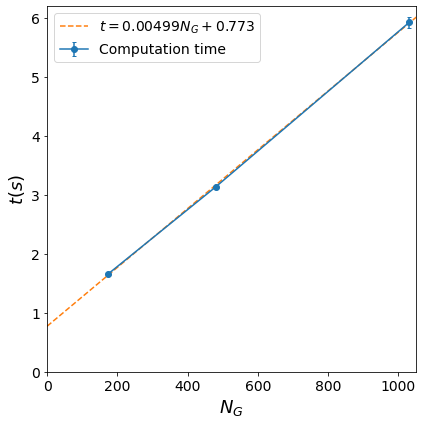

In [22]:
reg = stats.linregress(NGFStars, time_means)

x = np.linspace(0, 1150, 100)
y = reg.slope*x + reg.intercept

fig = plt.figure(figsize=(6,6))
ax1 = fig.add_subplot(111)
ax1.errorbar(NGFStars, time_means, time_stddevs, capsize=2, marker="o", label="Computation time")
ax1.set_xlim(0, 1050)
ax1.set_ylim(0, 6.2)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_xlabel(r'$N_{G}$', fontsize=18)
ax1.set_ylabel(r'$t(s)$', fontsize=18)
ax1.plot(x,y, ls="--", label=r'$t={:.3}N_G + {:.3}$'.format(reg.slope, reg.intercept))
ax1.legend(fontsize=14)
plt.tight_layout()
plt.savefig("Timing_std.png")
plt.savefig("Timing_2.png")

As we can see, the mean times are in close agreement with the results reported in our paper, which was performed on the same machine. On different machines, different times may be observed, but they should typically be a few seconds as we have shown here.

The current machine was a lenovo ideadpad laptop with an intel core i5 processor.